# ETL

In [1]:
import pandas as pd 
df_drift = pd.read_csv('data/drifting_longlines.csv')
df_drift.shape

(13968727, 10)

In [2]:
df_drift = df_drift.drop_duplicates(subset=['mmsi', 'timestamp', 'distance_from_shore', 'distance_from_port',
       'speed', 'course', 'lat', 'lon', 'is_fishing'])
df_drift.shape

(12745929, 10)

In [3]:
df_drift = df_drift[df_drift['is_fishing'] != -1]
df_drift.shape

(219741, 10)

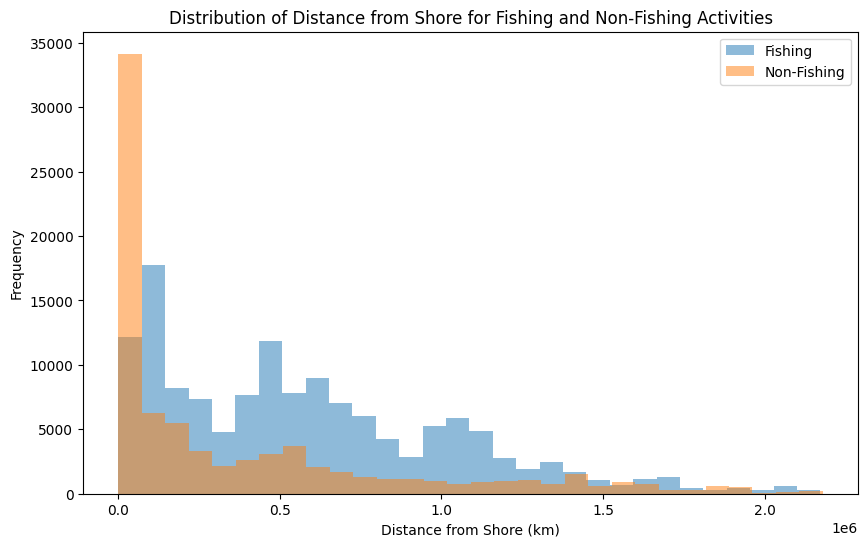

In [4]:
# plotting the distribution of the distance from shore for fishing and non-fishing activities
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(df_drift[df_drift['is_fishing'] == 1]['distance_from_shore'], bins=30, alpha=0.5, label='Fishing')
plt.hist(df_drift[df_drift['is_fishing'] == 0]['distance_from_shore'], bins=30, alpha=0.5, label='Non-Fishing')
plt.xlabel('Distance from Shore (km)')
plt.ylabel('Frequency')
plt.title('Distribution of Distance from Shore for Fishing and Non-Fishing Activities')
plt.legend()
plt.show()

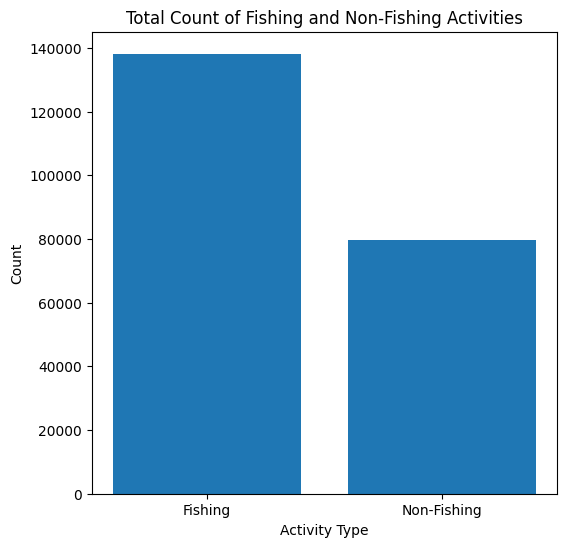

In [6]:
# plot total de fishing and non-fishing activities
plt.figure(figsize=(6, 6))
counts = df_drift['is_fishing'].value_counts().reindex([1.0, 0.0], fill_value=0)
plt.bar(['Fishing', 'Non-Fishing'], counts.values)
plt.xlabel('Activity Type')
plt.ylabel('Count')
plt.title('Total Count of Fishing and Non-Fishing Activities')
plt.show()

# Data transformation

In [ ]:
# ! pip install scikit-learn

In [11]:
model_data = df_drift.drop(columns=['mmsi',"source"])
# converter o que não for 0 em is_fishing para 1
model_data['is_fishing'] = model_data['is_fishing'].apply(lambda x: 1 if x != 0 else 0)
# data split
from sklearn.model_selection import train_test_split

X = model_data.drop(columns=['is_fishing'])
y = model_data['is_fishing']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# data train normalization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




# Train

In [12]:
# treinar com multiplos modelos de classificação min 10 modelos de classificação e comparar os resultados
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import average_precision_score

# model sort by fastest to slowest to train
models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'KNN': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Extra Trees': ExtraTreesClassifier(),
    'Bagging': BaggingClassifier(),
}

# train models and compare results by accuracy, precision, recall, f1-score, roc_auc_score, average_precision_score
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    average_precision = average_precision_score(y_test, y_pred)
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1-score': f1,
        'roc_auc_score': roc_auc,
        'average_precision_score': average_precision
    }
results_df = pd.DataFrame(results).T
results_df.sort_values(by='accuracy', ascending=False)

,accuracy,precision,recall,f1-score,roc_auc_score,average_precision_score
Extra Trees,0.995609,0.994995,0.998148,0.996569,0.994630,0.994336
Random Forest,0.994516,0.993863,0.997579,0.995717,0.993337,0.993004
Bagging,0.991900,0.992750,0.994588,0.993668,0.990864,0.990835
Decision Tree,0.987645,0.989932,0.990742,0.990337,0.986452,0.986683
KNN,0.972605,0.974879,0.982446,0.978648,0.968814,0.968984
Gradient Boosting,0.883661,0.884301,0.941072,0.911804,0.861547,0.869848
SVM,0.878769,0.878463,0.940395,0.908375,0.855031,0.864192
AdaBoost,0.822249,0.837669,0.895353,0.865551,0.794090,0.816883
Naive Bayes,0.733122,0.759142,0.853018,0.803347,0.686941,0.741488
Logistic Regression,0.694714,0.717949,0.860210,0.782668,0.630969,0.706918


# Test with explicability